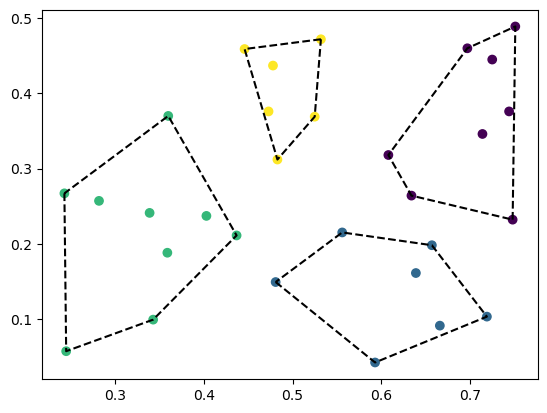

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

class AGNES:
    def __init__(self,k,d):
        """
        AGNES算法
        参数：
        k:簇的个数
        d:聚类簇距离的度量函数('single', 'complete', 'average')
        """
        self.k = k
        self.d = d
        self.M = None # 距离矩阵，用于保存各个样本之间的距离
        self.labels = None # 聚类标签


    def calculate_distance(self,C1,C2):
        """计算两个簇之间的距离"""
        # 单链接 公式(9.41)
        if self.d =='single':
            min_dist = np.inf
            for i in C1:
                for j in C2:
                    if self.M[i,j] < min_dist:
                        min_dist = self.M[i,j]
            return min_dist
        # 全链接 公式(9.42)
        elif self.d == 'complete':
            max_dist = -np.inf
            for i in C1:
                for j in C2:
                    if self.M[i,j] > max_dist:
                        max_dist = self.M[i,j]
            return max_dist
        # 平均链接 公式(9.43)
        elif self.d == 'average':
            dist_sum = 0
            for i in C1:
                for j in C2:
                    dist_sum += self.M[i,j]
            return dist_sum/len(C1)/len(C2)
        else:
            print('距离度量函数错误！')
            return None

    def fit(self,X):
        """训练"""
        m = X.shape[0] # 样本个数
        self.M = np.zeros((m,m)) # 距离矩阵初始化
        # 计算距离矩阵
        for i in range(m):
            for j in range(i+1,m):
                self.M[i,j] = self.M[j,i] = np.linalg.norm(X[i]-X[j])
        # 初始化用于更新的距离矩阵
        distance_matrix = self.M.copy() 
        # 初始化簇,每一个样本都是一个簇
        c = [[i] for i in range(m)]
        # 初始化当前簇的个数
        q = m
        # 聚类
        while q > self.k:
            # 选择最小距离的两个簇
            min_dist = np.inf
            for i in range(q):
                for j in range(i+1,q):
                    if distance_matrix[i,j] < min_dist:
                        min_dist = distance_matrix[i,j]
                        i_min,j_min = i,j
            # 合并两个簇
            c[i_min].extend(c[j_min])
            del c[j_min]

            # 更新距离矩阵
            distance_matrix = np.delete(distance_matrix,j_min,axis=0)
            distance_matrix = np.delete(distance_matrix,j_min,axis=1)
            for j in range(q-1):
                if j != i_min:
                    distance = self.calculate_distance(c[i_min],c[j])
                    distance_matrix[i_min,j] = distance
                    distance_matrix[j,i_min] = distance
                else:
                    distance_matrix[i_min,j] = 0
            
            q -= 1
    
        # 生成标签
        self.labels = np.zeros(m,dtype=int)
        for lable,samples in enumerate(c):
            for i in samples:
                self.labels[i] = lable
            
if __name__ == '__main__':
    # 加载数据
    data = np.loadtxt('../Data/4.0.csv',dtype = float,delimiter = ',')
    # 实例化AGNES，设置簇的个数为7，距离度量函数为全链接
    agnes = AGNES(k=4,d='complete')
    # 训练
    agnes.fit(data)
    # 可视化
    plt.scatter(data[:,0],data[:,1],c=agnes.labels)
    # 绘制每一个簇的凸包
    for i in range(agnes.k):
        points = data[agnes.labels == i]
        hull = ConvexHull(points).vertices.tolist()
        hull.append(hull[0])    
        plt.plot(points[hull,0],points[hull,1],'k--')
    plt.show()